# Testing new ART transmission and mortality

The goal is to allow for ART assignment to specify whether someone achieves EffectiveART or NonSuppressiveART, similar to ARTMortalityTable intervention from EMOD-HIV. 

I will implement, test, and demonstrate the following new model features

* New individual property which tracks ART Adherence - Effective vs NonSuppressive ART
* Allow Transmission to vary depending on Effective vs NonSuppressive ART
* Allow HIV-derived mortality to vary depending on Effective vs. NonSuppressive ART, as well as by age and sex

In [1]:
import starsim as ss
import stisim as sti
import matplotlib.pyplot as plt
import sciris as sc
import numpy as np
import pandas as pd

## Testing transmission

### Create a new class for testing mortality in each ART category

In [22]:
class ARTStatusTracker(ss.Analyzer):
    """
    Track deaths, living population, and onward transmissions, each broken
    out by ART-adherence category.

    Deaths need special handling: HIV.step_die() clears art_naive/on_art/
    on_effective_art/on_nonsuppressive_art/art_discontinued for agents who
    die (as it does for all disease states), so an agent's category can't be
    read off the live state after death. Instead, cache each agent's category
    at the end of every timestep, and when an agent dies (`ti_dead == ti`,
    which -- unlike the other states -- IS preserved through step_die), look
    up their most recently cached category rather than the (already-cleared)
    live state.

    Living population and transmission-source counts don't have this problem
    -- both only ever look at currently-alive, currently-infectious agents,
    so the live state is read directly, no caching needed.

    Requires `ss.infection_log()` to also be included in `analyzers=` for the
    transmission-attribution results to be populated (that's what actually
    turns on source/target tracking inside the HIV module).
    """
    CATEGORIES = ['art_naive', 'on_effective_art', 'on_nonsuppressive_art', 'art_discontinued']

    def __init__(self):
        super().__init__()
        self._cache = {}  # uid -> category, as of the end of the previous timestep

    def init_results(self):
        super().init_results()
        results = []
        for cat in self.CATEGORIES + ['on_art']:
            results += [
                ss.Result(f'deaths_{cat}', dtype=int, label=f'Deaths ({cat})'),
                ss.Result(f'n_alive_{cat}', dtype=int, label=f'Living with HIV ({cat})'),
                ss.Result(f'new_infections_from_{cat}', dtype=int, label=f'New infections from {cat}'),
            ]
        self.define_results(*results)

    def step(self):
        hiv = self.sim.diseases.hiv
        ti = self.ti

        # Deaths: attribute using each agent's cached (pre-death) category
        died_uids = (hiv.ti_dead == ti).uids
        for uid in died_uids:
            cat = self._cache.pop(int(uid), None)
            if cat is None:
                continue
            self.results[f'deaths_{cat}'][ti] += 1
            if cat in ('on_effective_art', 'on_nonsuppressive_art'):
                self.results['deaths_on_art'][ti] += 1

        # Onward transmissions this timestep, by source uid (requires ss.infection_log())
        log = hiv.infection_log
        new_source_uids = []
        if log is not None:
            for source, _target, t in log.edges(keys=True):
                if t == hiv.now and not pd.isna(source):
                    new_source_uids.append(int(source))
        src_uids = ss.uids(new_source_uids) if new_source_uids else ss.uids([])

        # Living population and transmission-source counts, by category
        for cat in self.CATEGORIES:
            alive_uids = (hiv.infected & hiv[cat]).uids
            n_alive = len(alive_uids)
            n_from_cat = int(hiv[cat][src_uids].sum()) if len(src_uids) else 0
            self.results[f'n_alive_{cat}'][ti] = n_alive
            self.results[f'new_infections_from_{cat}'][ti] = n_from_cat
            if cat in ('on_effective_art', 'on_nonsuppressive_art'):
                self.results['n_alive_on_art'][ti] += n_alive
                self.results['new_infections_from_on_art'][ti] += n_from_cat

        # Refresh the death-attribution cache for next timestep
        for cat in self.CATEGORIES:
            for uid in hiv[cat].uids:
                self._cache[int(uid)] = cat


def get_by_art_status(sim, metric):
    """
    Extract a result time series stratified by ART status.

    Args:
        sim: a run Sim with an ARTStatusTracker analyzer attached
        metric (str): result prefix -- one of 'deaths', 'n_alive', 'new_infections_from'

    Returns:
        dict mapping category name -> np.array (one value per timestep),
        for each of ARTStatusTracker.CATEGORIES plus the 'on_art' aggregate
    """
    tracker = sim.analyzers.artstatustracker
    groups = ARTStatusTracker.CATEGORIES + ['on_art']
    return {cat: tracker.results[f'{metric}_{cat}'].values for cat in groups}

### Run simulation

In [23]:
# Diagnose people first -- ART only initiates agents who are hiv.diagnosed.
hiv_test = sti.HIVTest(test_prob_data=0.3, start=2000)

# Absolute-count coverage target: ramps from 0 to 1000 people on ART between
# 2004 and 2005, then holds at 1000 for the rest of the sim. 50/50 split
# between effective (virally-suppressive) and non-suppressive ART.
art = sti.ART(
    coverage={'year': [2004, 2005], 'value': [0, 1000], 'format': 'n'},
    p_effective_art=0.5,
)
art_tracker = ARTStatusTracker()

sim = sti.Sim(
    diseases=sti.HIV(init_prev=ss.bernoulli(p=0.2)),
    n_agents=10_000, start=2000, stop=2020,
    interventions=[hiv_test, art],
    analyzers=[ss.infection_log(), art_tracker],
    rand_seed=2
)
sim.run(verbose=0)

Initializing sim with 10000 agents


Sim(n=10000; 2000—2020; networks=structuredsexual, maternalnet; diseases=hiv; interventions=hivtest, art; analyzers=infection_log, artstatustracker)

### Checking simulaiton results

In [24]:
hiv_res = sim.results.hiv
timevec = hiv_res.timevec
groups = ARTStatusTracker.CATEGORIES + ['on_art']

print(f"Final counts: on_effective_art={hiv_res.n_on_effective_art[-1]:.0f}, "
      f"on_nonsuppressive_art={hiv_res.n_on_nonsuppressive_art[-1]:.0f}")

Final counts: on_effective_art=530, on_nonsuppressive_art=449


#### Plot the numbers of people on effective vs. non-suppressive ART

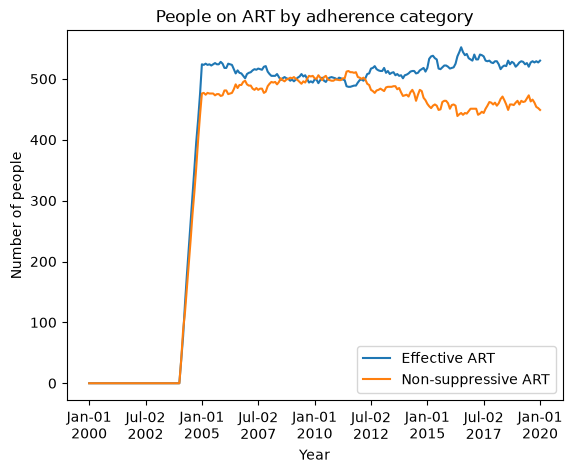

In [25]:
# Plot 1: number of people on effective vs. non-suppressive ART over time
fig1, ax1 = plt.subplots()
ax1.plot(timevec, hiv_res.n_on_effective_art, label='Effective ART')
ax1.plot(timevec, hiv_res.n_on_nonsuppressive_art, label='Non-suppressive ART')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of people')
ax1.set_title('People on ART by adherence category')
ax1.legend()

#### Plot number and rates of deaths by ART status

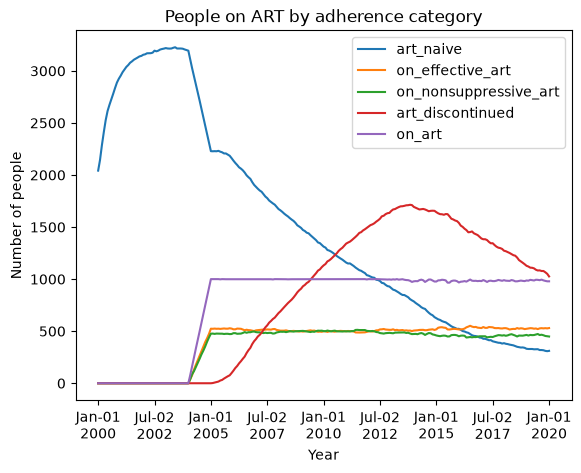

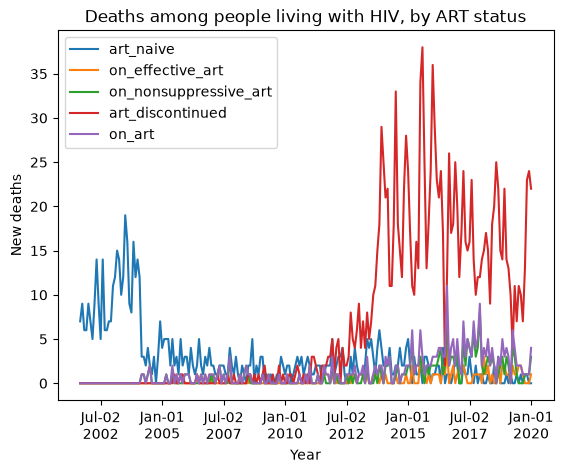

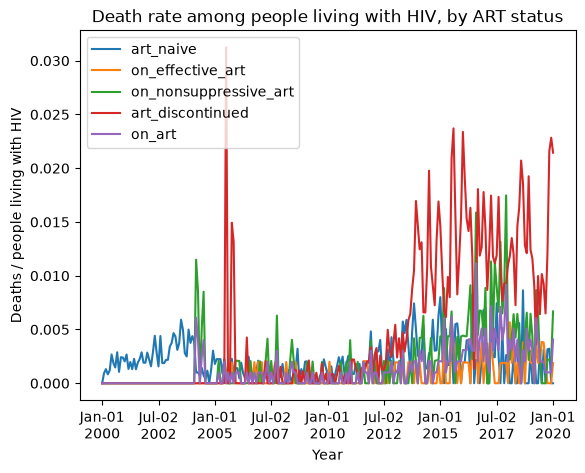

In [26]:
pops = get_by_art_status(sim, 'n_alive')
fig1, ax1 = plt.subplots()
for cat in groups:
    ax1.plot(timevec, pops[cat], label=cat)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of people')
ax1.set_title('People on ART by adherence category')
ax1.legend()

# Plot 2: count of deaths among people living with HIV, by ART status
deaths = get_by_art_status(sim, 'deaths')
fig2, ax2 = plt.subplots()
for cat in groups:
    ax2.plot(timevec[20:], deaths[cat][20:], label=cat)
ax2.set_xlabel('Year')
ax2.set_ylabel('New deaths')
ax2.set_title('Deaths among people living with HIV, by ART status')
ax2.legend()

# Plot 3: death RATE (deaths / people living with HIV), by ART status
n_alive = get_by_art_status(sim, 'n_alive')
fig3, ax3 = plt.subplots()
for cat in groups:
    rate = np.divide(deaths[cat], n_alive[cat],
                      out=np.zeros_like(deaths[cat], dtype=float), where=(n_alive[cat] > 0))
    ax3.plot(timevec, rate, label=cat)
ax3.set_xlabel('Year')
ax3.set_ylabel('Deaths / people living with HIV')
ax3.set_title('Death rate among people living with HIV, by ART status')
ax3.legend()

#### Count numbers of onward transmissions

/var/folders/bd/msk_4j2n33xd2gh_w3_ts2sr0000gr/T/ipykernel_80742/3213775394.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


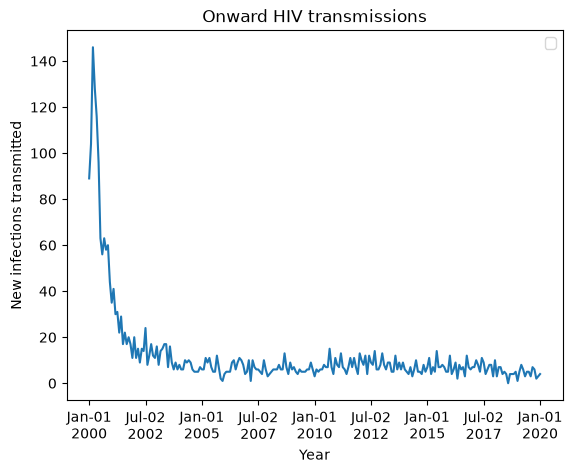

In [28]:
fig4, ax4 = plt.subplots()

ax4.plot(timevec, sim.results.hiv.new_infections)
ax4.set_xlabel('Year')
ax4.set_ylabel('New infections transmitted')
ax4.set_title('Onward HIV transmissions')
ax4.legend()

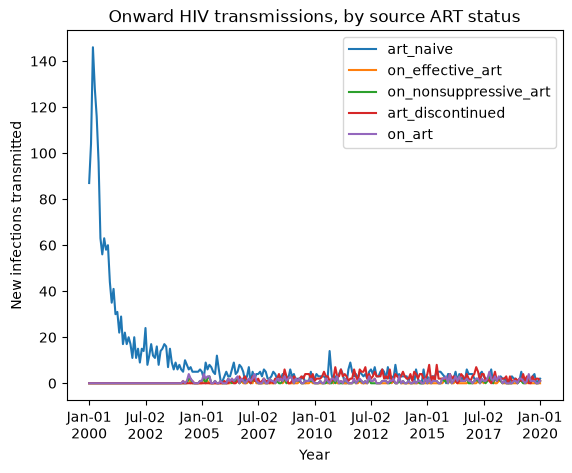

In [29]:
# Plot 4: onward transmissions, stratified by the SOURCE's ART status
new_infections = get_by_art_status(sim, 'new_infections_from')
fig4, ax4 = plt.subplots()
for cat in groups:
    ax4.plot(timevec, new_infections[cat], label=cat)
ax4.set_xlabel('Year')
ax4.set_ylabel('New infections transmitted')
ax4.set_title('Onward HIV transmissions, by source ART status')
ax4.legend()

/Users/daniel/miniforge3/envs/hivsim-dev/lib/python3.13/site-packages/starsim/arrays.py:77: RuntimeWarning: invalid value encountered in divide
  result = getattr(ufunc, method)(*inputs, **kwargs)


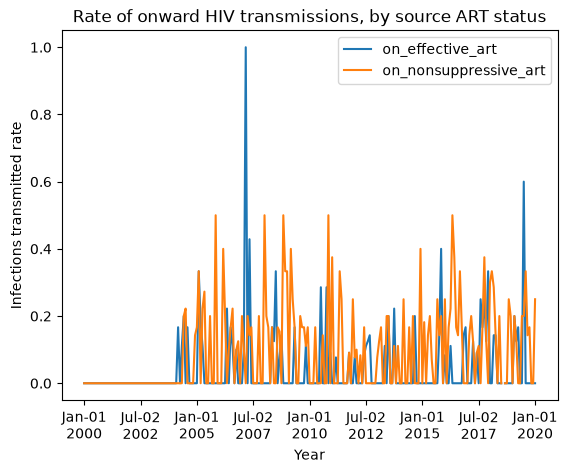

In [30]:
# Plot 5: onward transmissions, stratified by the SOURCE's ART status
new_infections = get_by_art_status(sim, 'new_infections_from')
n_alive = get_by_art_status(sim, 'n_alive')
fig5, ax5 = plt.subplots()
for cat in ['on_effective_art', 'on_nonsuppressive_art']:#groups:
    #ax5.plot(timevec, new_infections[cat]/n_alive[cat], label=cat)
    ax5.plot(timevec, new_infections[cat]/sim.results.hiv.new_infections, label=cat)
ax5.set_xlabel('Year')
ax5.set_ylabel('Infections transmitted rate')
ax5.set_title('Rate of onward HIV transmissions, by source ART status')
ax5.legend()

In [ ]:
for cat in groups:
    print(cat, new_infections[cat].sum())

age_bins = [(0, 15), (15, 25), (25, 35), (35, 45), (45, 55), (55, 65), (65, 100)]
age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]

df = run_duration_test(age_bins, n_agents=10_000, start=2000, stop=2040)

print('=== Check 1: baseline (HIV.dur_on_art, no age dependence) ===')
print_duration_summary(df, age_labels)
plot_duration_histograms(df, age_labels)
plot_km_by_age(df, age_labels)

# Testing duration on ART

Initializing sim with 10000 agents

=== Check 2: age-dependent exponential dropout hazard (AgeDependentARTDropout) ===
15-25: n=624 (616 completed, 8 censored), completed mean/median=6.24/4.42 yr, KM restricted mean (lower bound)=6.54 yr
25+: n=2726 (2305 completed, 421 censored), completed mean/median=12.03/10.25 yr, KM restricted mean (lower bound)=15.76 yr
overall: n=3350 (2921 completed, 429 censored), completed mean/median=10.81/8.67 yr, KM restricted mean (lower bound)=14.04 yr


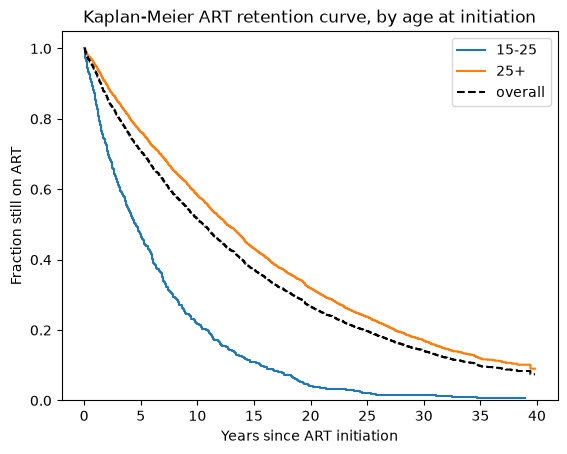

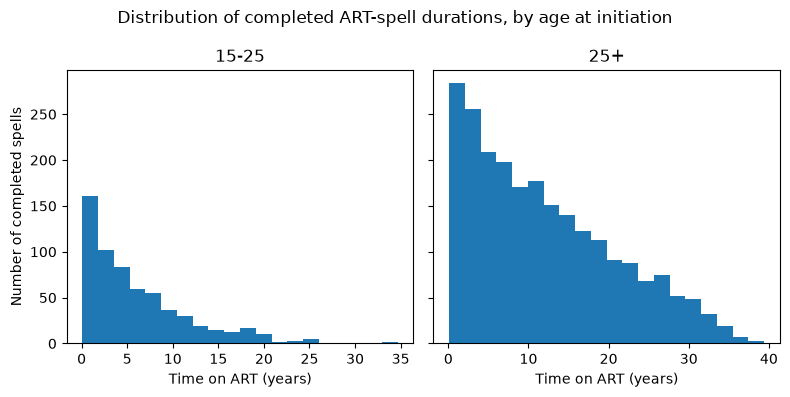

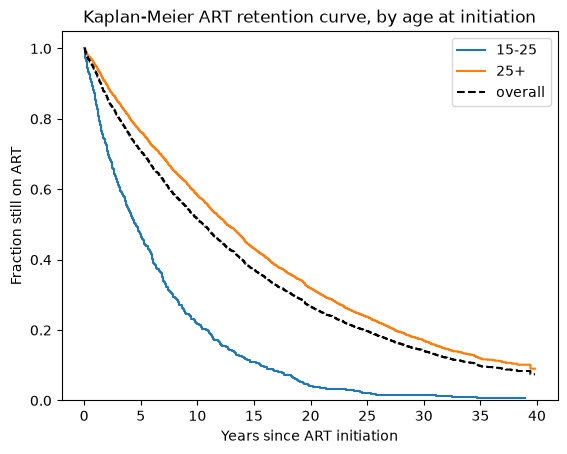

In [40]:
age_dropout = [(15, 25, 20 / 3), (25, 200, 20)]  # (age_lo, age_hi, mean retention years = 1/annual_dropout_rate)
age_dropout_labels = [_bin_label(lo, hi) for lo, hi, _ in age_dropout]

df_custom = run_duration_test_age_dropout(age_dropout, min_age=15, n_agents=10_000, start=2000, stop=2040)

print()
print('=== Check 2: age-dependent exponential dropout hazard (AgeDependentARTDropout) ===')
print_duration_summary(df_custom, age_dropout_labels)
plot_duration_histograms(df_custom, age_dropout_labels)
plot_km_by_age(df_custom, age_dropout_labels)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import starsim as ss
import stisim as sti

def _bin_label(lo, hi, open_ended_at=200):
    return f'{lo}-{hi}' if hi < open_ended_at else f'{lo}+'


def _age_band(age, age_bins):
    for lo, hi in age_bins:
        if lo <= age < hi:
            return _bin_label(lo, hi)
    return None


class AgeSexAdherenceMortalityTracker(ss.Analyzer):
    """
    Tracks deaths and person-years, stratified by (user-specified) age
    bracket, sex, and treatment status: ART adherence category (effective
    vs. non-suppressive) for people on ART, plus a separate 'off_art'
    category (infected but not currently on ART, i.e. ART-naive or
    discontinued) for comparison.

    Deaths are attributed using each agent's (age bracket, sex, status) as
    of the END of the PREVIOUS timestep, cached across steps -- the same
    pattern ARTStatusTracker uses in art_transmission_test.py, and for the
    same reason: HIV.step_die() clears on_effective_art/on_nonsuppressive_art
    for agents who die this step, so the live state can't be read after
    the fact.
    """
    ADHERENCE = ['on_effective_art', 'on_nonsuppressive_art']  # on-ART categories only (used for old-vs-new comparisons)
    OFF_ART = 'off_art'  # infected & not on ART (art_naive or art_discontinued); mortality here is identical old vs. new

    def __init__(self, age_bins):
        super().__init__()
        self.age_bins = age_bins
        self.age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
        self._cache = {}  # uid -> (age_label, sex, status), as of end of previous timestep

    def init_results(self):
        super().init_results()
        results = []
        for age_label in self.age_labels:
            for sex in ('m', 'f'):
                for cat in self.ADHERENCE + [self.OFF_ART]:
                    key = f'{age_label}_{sex}_{cat}'
                    results += [
                        ss.Result(f'deaths_{key}', dtype=int),
                        ss.Result(f'person_years_{key}', dtype=float),
                    ]
        self.define_results(*results)

    def step(self):
        hiv = self.sim.diseases.hiv
        ti = self.ti
        ppl = self.sim.people
        dt_years = self.dt.years

        # Deaths this step, attributed via the pre-death cache
        died_uids = (hiv.ti_dead == ti).uids
        for uid in died_uids:
            cached = self._cache.pop(int(uid), None)
            if cached is None:
                continue
            label, sex, cat = cached
            self.results[f'deaths_{label}_{sex}_{cat}'][ti] += 1

        # Person-time this step, by CURRENT age band/sex/status
        cache = {}
        for cat, uids in [*((cat, hiv[cat].uids) for cat in self.ADHERENCE),
                           (self.OFF_ART, (hiv.infected & ~hiv.on_art).uids)]:
            for uid in uids:
                u = ss.uids([uid])
                label = _age_band(ppl.age[u][0], self.age_bins)
                if label is None:
                    continue
                sex = 'm' if bool(ppl.male[u][0]) else 'f'
                self.results[f'person_years_{label}_{sex}_{cat}'][ti] += dt_years
                cache[int(uid)] = (label, sex, cat)
        self._cache = cache


def run_mortality_comparison(age_bins, n_agents=10_000, start=2000, stop=2020, coverage_target=0.6):
    """
    Run identical scenarios with the old (art_death_rate=0, i.e. zero on-ART
    mortality) and new (PR #561 default closed-form rate) behavior, and
    return each run's tracker plus the shared calendar-year time vector.
    """
    trackers = {}
    sim = None
    for version, art_death_rate in [('old', 0.0), ('new', None)]:  # None = use this branch's own default
        hiv_kwargs = dict(init_prev=ss.bernoulli(p=0.2))
        if art_death_rate is not None:
            hiv_kwargs['art_death_rate'] = art_death_rate

        hiv_test = sti.HIVTest(test_prob_data=0.3, start=start)
        ramp_end = min(start + 4, stop)
        art = sti.ART(coverage={'year': [start, ramp_end, stop], 'value': [0, coverage_target, coverage_target]}, p_effective_art=0.5)
        sim = sti.Sim(
            diseases=sti.HIV(**hiv_kwargs),
            n_agents=n_agents, start=start, stop=stop,
            interventions=[hiv_test, art],
            analyzers=[AgeSexAdherenceMortalityTracker(age_bins)],
        )
        sim.run(verbose=0)
        trackers[version] = sim.analyzers.agesexadherencemortalitytracker
    return trackers, sim.t.yearvec  # yearvec is identical for both runs (same start/stop/dt)


def summarize_mortality_comparison(trackers, yearvec, age_bins, date_range=None):
    """
    Build a tidy DataFrame of annual death rate (deaths / person-years), one
    row per (version, age band, sex, adherence category), aggregated only
    over timesteps whose calendar year falls in date_range.

    Args:
        date_range (tuple, optional): (start_year, end_year), inclusive of
            start_year and exclusive of end_year. Defaults to the full run.
    """
    if date_range is None:
        mask = np.ones(len(yearvec), dtype=bool)
    else:
        lo, hi = date_range
        mask = (yearvec >= lo) & (yearvec < hi)

    age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
    rows = []
    for version, tracker in trackers.items():
        for age_label in age_labels:
            for sex in ('m', 'f'):
                for cat in AgeSexAdherenceMortalityTracker.ADHERENCE:
                    key = f'{age_label}_{sex}_{cat}'
                    deaths = tracker.results[f'deaths_{key}'].values[mask].sum()
                    person_years = tracker.results[f'person_years_{key}'].values[mask].sum()
                    rate = deaths / person_years if person_years > 0 else np.nan
                    rows.append(dict(version=version, age_band=age_label, sex=sex, adherence=cat,
                                      deaths=deaths, person_years=person_years, annual_death_rate=rate))
    return pd.DataFrame(rows)



def yearly_mortality_by_adherence(trackers, yearvec, age_bins):
    """
    Total mortality per calendar year, pooled across all age brackets and
    both sexes, broken out into four categories: 'any' (on ART of any kind,
    i.e. effective + non-suppressive combined), 'effective', 'nonsuppressive',
    and 'off_art' (infected but not currently on ART). One row per
    (version, year, category).

    Note 'off_art' mortality is computed by the same code path regardless of
    `art_death_rate`, so old vs. new should only differ there by simulation
    noise -- it's included for a full picture, not because the ART-mortality
    setting is expected to change it.
    """
    all_cats = AgeSexAdherenceMortalityTracker.ADHERENCE + [AgeSexAdherenceMortalityTracker.OFF_ART]
    age_labels = [_bin_label(lo, hi) for lo, hi in age_bins]
    years = np.floor(yearvec).astype(int)
    unique_years = sorted(set(years))

    rows = []
    for version, tracker in trackers.items():
        # Sum deaths/person-years across all age brackets and sexes, per timestep, per category
        deaths_by_cat = {cat: np.zeros(len(yearvec)) for cat in all_cats}
        py_by_cat = {cat: np.zeros(len(yearvec)) for cat in all_cats}
        for cat in all_cats:
            for age_label in age_labels:
                for sex in ('m', 'f'):
                    key = f'{age_label}_{sex}_{cat}'
                    deaths_by_cat[cat] += tracker.results[f'deaths_{key}'].values
                    py_by_cat[cat] += tracker.results[f'person_years_{key}'].values

        deaths_any = deaths_by_cat['on_effective_art'] + deaths_by_cat['on_nonsuppressive_art']
        py_any = py_by_cat['on_effective_art'] + py_by_cat['on_nonsuppressive_art']

        by_category = [
            ('any', deaths_any, py_any),
            ('effective', deaths_by_cat['on_effective_art'], py_by_cat['on_effective_art']),
            ('nonsuppressive', deaths_by_cat['on_nonsuppressive_art'], py_by_cat['on_nonsuppressive_art']),
            ('off_art', deaths_by_cat[AgeSexAdherenceMortalityTracker.OFF_ART], py_by_cat[AgeSexAdherenceMortalityTracker.OFF_ART]),
        ]
        for year in unique_years:
            mask = years == year
            for category, deaths_arr, py_arr in by_category:
                deaths = deaths_arr[mask].sum()
                person_years = py_arr[mask].sum()
                rate = deaths / person_years if person_years > 0 else np.nan
                rows.append(dict(version=version, year=year, category=category,
                                  deaths=deaths, person_years=person_years, annual_death_rate=rate))
    return pd.DataFrame(rows)


def plot_yearly_mortality(yearly):
    """ Annual death rate (deaths / person-years on ART) per year, one panel per category, old vs. new overlaid. """
    categories = ['any', 'effective', 'nonsuppressive', 'off_art']
    fig, axes = plt.subplots(1, len(categories), figsize=(5 * len(categories), 4), sharey=True)
    for ax, category in zip(axes, categories):
        for version, color in [('old', 'tab:gray'), ('new', 'tab:blue')]:
            sub = yearly.query('version == @version and category == @category').sort_values('year')
            ax.plot(sub['year'], sub['annual_death_rate'], marker='o', label=version, color=color)
        ax.set_title(category)
        ax.set_xlabel('Year')
        ax.legend()
    axes[0].set_ylabel('Annual death rate (deaths / person-years)')
    fig.suptitle('Old (art_death_rate=0) vs. new (PR #561 default): annual death rate per year, by ART status')
    fig.tight_layout()
    return fig


def plot_mortality_comparison(comparison, age_labels):
    """
    Grid of bar-chart panels: rows = sex, columns = ART adherence category.
    Each panel shows old vs. new annual on-ART death rate per age bracket.
    """
    adherence_cats = AgeSexAdherenceMortalityTracker.ADHERENCE
    fig, axes = plt.subplots(2, len(adherence_cats), figsize=(5.5 * len(adherence_cats), 7), sharey=True)
    x = np.arange(len(age_labels))
    width = 0.35
    for row, sex in enumerate(('m', 'f')):
        for col, cat in enumerate(adherence_cats):
            ax = axes[row, col]
            for offset, version, color in [(-1, 'old', 'tab:gray'), (1, 'new', 'tab:blue')]:
                rates = [
                    comparison.query('version == @version and sex == @sex and adherence == @cat and age_band == @label')['annual_death_rate'].iloc[0]
                    for label in age_labels
                ]
                ax.bar(x + offset * width / 2, rates, width, label=version, color=color)
            ax.set_xticks(x)
            ax.set_xticklabels(age_labels)
            ax.set_title(f'{cat}, sex={sex}')
            if col == 0:
                ax.set_ylabel('Annual death rate while on ART')
            ax.legend()
    fig.suptitle('Old (art_death_rate=0) vs. new (PR #561 closed-form function) on-ART mortality, by age and sex')
    fig.tight_layout()
    return fig

## Mortality rate broken down by age and sex

In [1]:
from art_adherence_test_3 import *

def _bin_label(lo, hi, open_ended_at):
    return f'{lo}-{hi}' if hi < open_ended_at else f'{lo}+'


def _bin_lookup(value, bins, open_ended_at):
    for lo, hi in bins:
        if lo <= value < hi:
            return _bin_label(lo, hi, open_ended_at)
    return None

In [2]:
age_bins = [(0, 25), (25, 35), (35, 45), (45, 200)]
cd4_bins = [(0, 200), (200, 350), (350, 500), (500, 100_000)]

In [ ]:
tracker = run_sim(age_bins, cd4_bins, n_agents=100_000, start=2000, stop=2030)

## Females

In [11]:
SEX = 'f'  # 'm' or 'f'

summary = summarize_mortality_by_status(tracker, age_bins, cd4_bins, sex=SEX)

print(f'Annual HIV death rate by ART status, age x CD4, sex={SEX}:')
print(summary.pivot_table(index=['age_band', 'cd4_band'], columns='category',
                           values='annual_death_rate').to_string(float_format='%.4f'))
print()
check_off_art_higher(summary)


Annual HIV death rate by ART status, age x CD4, sex=f:
category           off_art  on_effective_art  on_nonsuppressive_art  total
age_band cd4_band                                                         
0-25     0-200      0.6092            0.0164                 0.0547 0.4161
         200-350    0.0615            0.0000                 0.0037 0.0432
         350-500    0.0095            0.0011                 0.0022 0.0085
         500+       0.0047            0.0005                 0.0018 0.0025
25-35    0-200      0.4391            0.0136                 0.0608 0.3170
         200-350    0.0220            0.0018                 0.0018 0.0160
         350-500    0.0073            0.0017                 0.0000 0.0062
         500+       0.0038            0.0004                 0.0012 0.0019
35-45    0-200      0.3552            0.0262                 0.0591 0.2392
         200-350    0.0248            0.0014                 0.0068 0.0180
         350-500    0.0074            0.0010 

category            off_art  on_effective_art  on_nonsuppressive_art
age_band cd4_band                                                   
0-25     0-200     0.609211          0.016364               0.054723
         200-350   0.061459          0.000000               0.003670
         350-500   0.009487          0.001064               0.002151
         500+      0.004699          0.000458               0.001761
25-35    0-200     0.439134          0.013590               0.060795
         200-350   0.022039          0.001776               0.001846
         350-500   0.007255          0.001742               0.000000
         500+      0.003799          0.000385               0.001206
35-45    0-200     0.355208          0.026239               0.059144
         200-350   0.024800          0.001412               0.006826
         350-500   0.007442          0.001001               0.003055
         500+      0.003688          0.000744               0.001889
45+      0-200     0.304738          0.019090               0.051012
         200-350   0.018570          0.001551               0.008798
         350-500   0.006187          0.001300               0.003309
         500+      0.002914          0.000674               0.002130

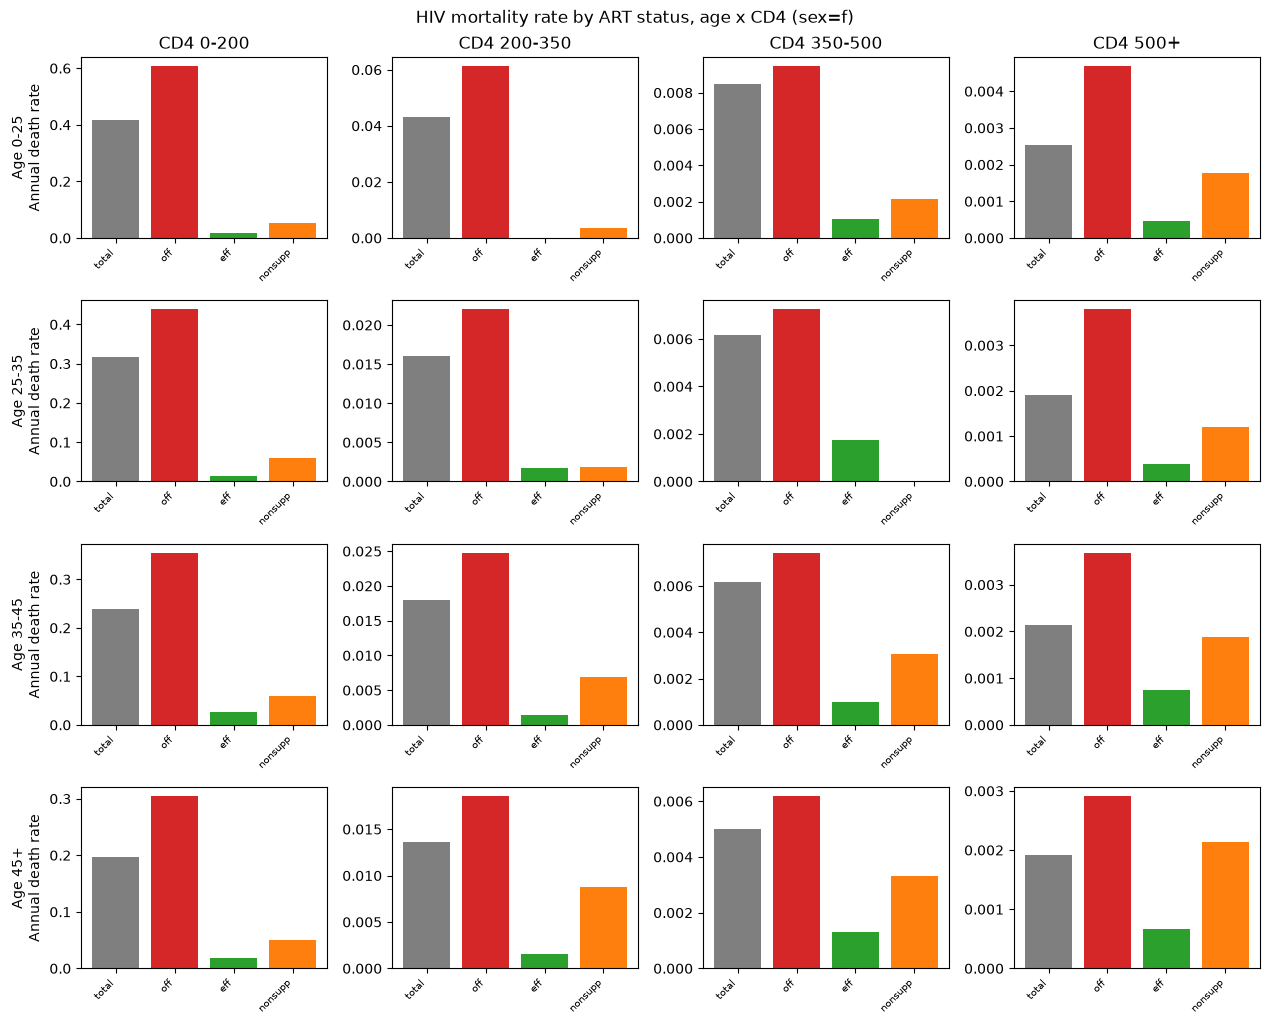

In [12]:
age_labels = [_bin_label(lo, hi, AgeCD4ARTMortalityTracker.AGE_OPEN_ENDED_AT) for lo, hi in age_bins]
cd4_labels = [_bin_label(lo, hi, AgeCD4ARTMortalityTracker.CD4_OPEN_ENDED_AT) for lo, hi in cd4_bins]
plot_mortality_by_status(summary, age_labels, cd4_labels, sex=SEX)

plt.show()

## Males

In [9]:
SEX = 'm'  # 'm' or 'f'

#tracker = run_sim(age_bins, cd4_bins, n_agents=100_000, start=2000, stop=2030)
summary = summarize_mortality_by_status(tracker, age_bins, cd4_bins, sex=SEX)

print(f'Annual HIV death rate by ART status, age x CD4, sex={SEX}:')
print(summary.pivot_table(index=['age_band', 'cd4_band'], columns='category',
                           values='annual_death_rate').to_string(float_format='%.4f'))
print()
check_off_art_higher(summary)

Annual HIV death rate by ART status, age x CD4, sex=m:
category           off_art  on_effective_art  on_nonsuppressive_art  total
age_band cd4_band                                                         
0-25     0-200      0.6400            0.0396                 0.0741 0.4482
         200-350    0.0781            0.0000                 0.0112 0.0557
         350-500    0.0131            0.0014                 0.0040 0.0115
         500+       0.0037            0.0011                 0.0024 0.0025
25-35    0-200      0.4448            0.0263                 0.0935 0.3192
         200-350    0.0463            0.0000                 0.0055 0.0322
         350-500    0.0074            0.0000                 0.0042 0.0066
         500+       0.0028            0.0008                 0.0022 0.0020
35-45    0-200      0.4360            0.0866                 0.0754 0.3293
         200-350    0.0270            0.0000                 0.0130 0.0206
         350-500    0.0065            0.0006 

category            off_art  on_effective_art  on_nonsuppressive_art
age_band cd4_band                                                   
0-25     0-200     0.640023          0.039604               0.074120
         200-350   0.078133          0.000000               0.011215
         350-500   0.013109          0.001450               0.003990
         500+      0.003748          0.001109               0.002414
25-35    0-200     0.444751          0.026301               0.093525
         200-350   0.046307          0.000000               0.005543
         350-500   0.007427          0.000000               0.004153
         500+      0.002750          0.000834               0.002199
35-45    0-200     0.435995          0.086626               0.075444
         200-350   0.026961          0.000000               0.012989
         350-500   0.006498          0.000576               0.002224
         500+      0.002770          0.000972               0.002781
45+      0-200     0.318420          0.032583               0.078778
         200-350   0.019893          0.002486               0.008378
         350-500   0.006968          0.001390               0.003934
         500+      0.003127          0.001062               0.002741

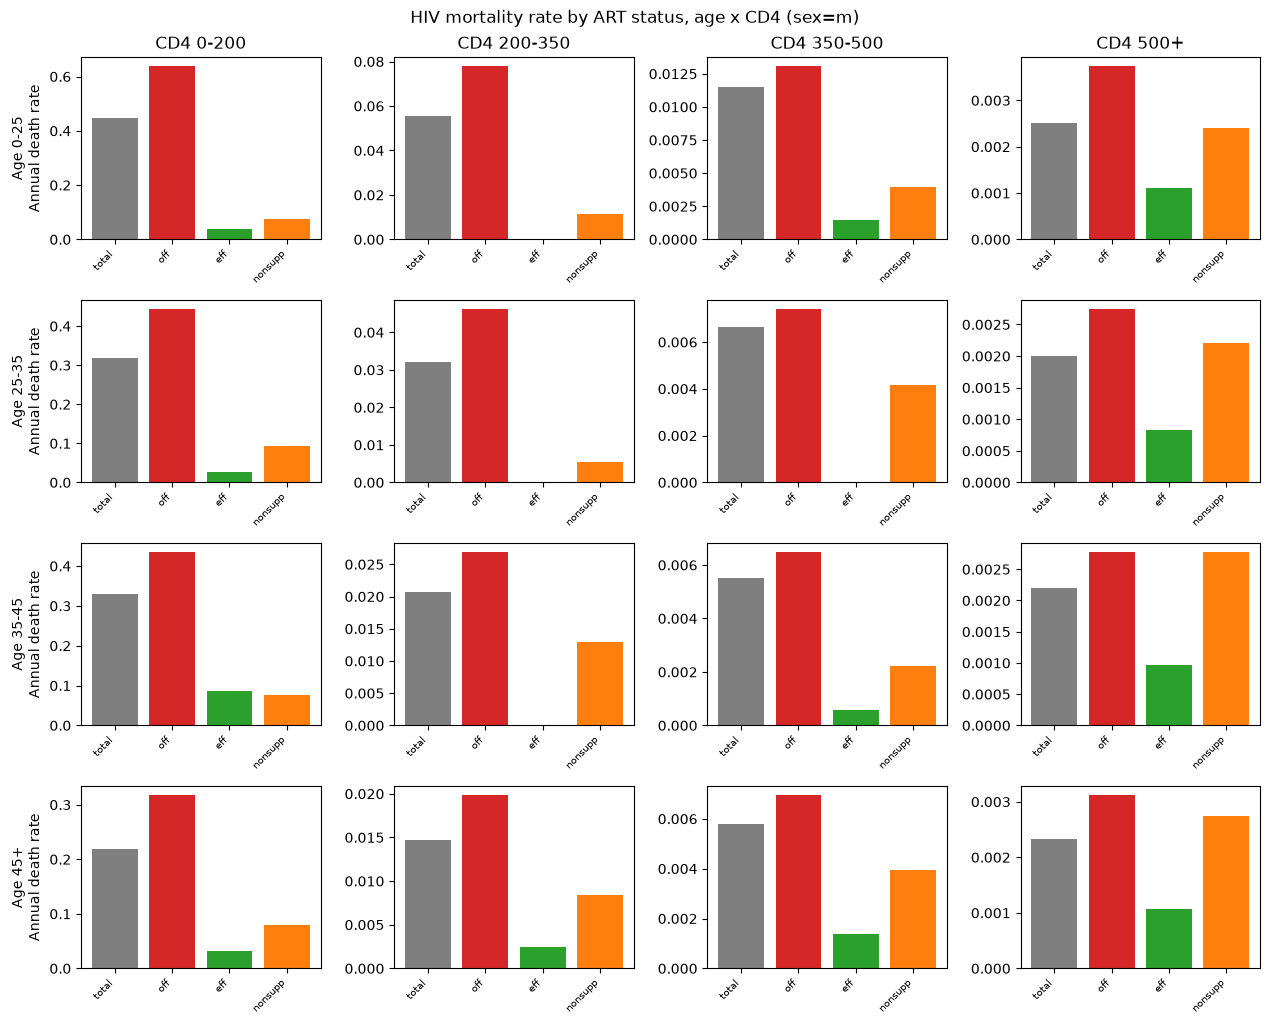

In [10]:
age_labels = [_bin_label(lo, hi, AgeCD4ARTMortalityTracker.AGE_OPEN_ENDED_AT) for lo, hi in age_bins]
cd4_labels = [_bin_label(lo, hi, AgeCD4ARTMortalityTracker.CD4_OPEN_ENDED_AT) for lo, hi in cd4_bins]
plot_mortality_by_status(summary, age_labels, cd4_labels, sex=SEX)

plt.show()

--- Off-ART CD4 bins/rates (HIVPars.cd4_death_bins/cd4_death_rates), shared with on-ART ---
 cd4_bin_upper  rate
          1000 0.003
           500 0.003
           350 0.005
           200 0.010
            50 0.050
             0 0.300
  (rel_death = 1.0 multiplies these, for both off-ART and on-ART)
--- Relative-mortality factors (fraction of off-ART rate retained on ART) ---
  rel_art_mortality_effective: 0.25
  rel_art_mortality_unsupp (non-suppressive ART): 0.7
  rel_death_f (female, on ART): 0.74
--- On-ART age_mult (HIVPars.art_death_age) ---
 age_lo  age_hi  mult
      0      25  1.00
     25      35  1.10
     35      45  1.21
     45     125  1.32

Worst-case combined multiplier (non-suppressive, oldest age band, male): 0.7 * 1.32 = 0.9240
  --> <= 1: on-ART mortality can never exceed off-ART mortality at the same CD4, for any age/sex/adherence.
===== Closed-form annual mortality rate, sex=m =====
--- off_art ---
cd4  0     200    350    500    1000
age                     

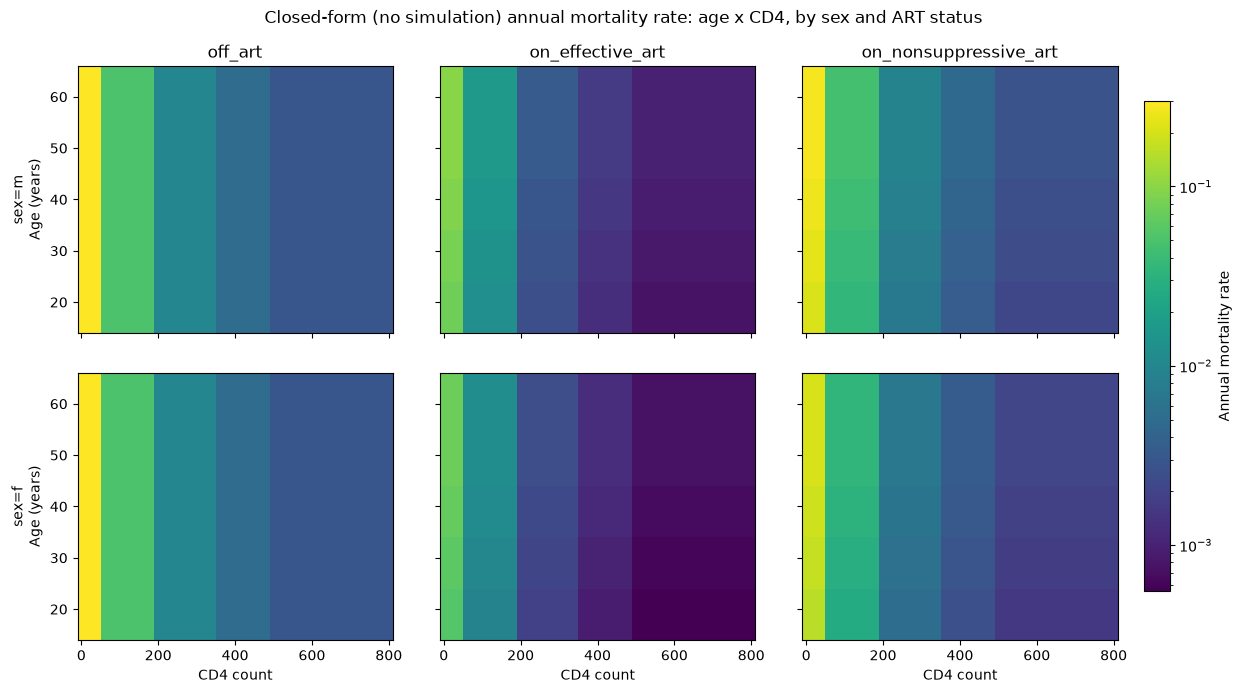

In [5]:
print_multiplier_stages()

age_bins = [(0, 25), (25, 35), (35, 45), (45, 200)]
cd4_bins = [(0, 200), (200, 350), (350, 500), (500, 100_000)]

analytic_age_vals = np.array([0,25, 35, 45, 55, 65])
analytic_cd4_vals = np.array([0, 200, 350,500, 1000])
analytic_grids = compute_analytic_grids(analytic_age_vals, analytic_cd4_vals)
print_analytic_tables(analytic_age_vals, analytic_cd4_vals, analytic_grids)

fine_age_vals = np.arange(15, 66, 2)
fine_cd4_vals = np.arange(0, 810, 20)
fine_grids = compute_analytic_grids(fine_age_vals, fine_cd4_vals)
plot_analytic_heatmaps(fine_age_vals, fine_cd4_vals, fine_grids)

plt.show()

# ART Mortality vs Adherence Tests

* This will first show the yearly mortality rate by ART status
* Run a simulation, and read out the mortality rate by age, sex, and CD4 count.
    * Should show how HIV-related mortality is always highest while off of ART, then among people who are on nonsuppressive ART, then among people on effective ART, for all age, sex, CD4 counts
* Analytical lookups of mortality rate by age, sex, and CD4 count, should verify the simulated numerical patterns shown previously 

In [1]:
from art_adherence_test import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import starsim as ss
import stisim as sti


def _bin_label(lo, hi, open_ended_at):
    return f'{lo}-{hi}' if hi < open_ended_at else f'{lo}+'


def _bin_lookup(value, bins, open_ended_at):
    for lo, hi in bins:
        if lo <= value < hi:
            return _bin_label(lo, hi, open_ended_at)
    return None

In [12]:
age_bins = [(0, 25), (25, 35), (35, 45), (45, 200)]
cd4_bins = [(0, 200), (200, 350), (350, 500), (500, 100_000)]

age_labels = [_bin_label(lo, hi, AgeCD4ARTMortalityTracker.AGE_OPEN_ENDED_AT) for lo, hi in age_bins]
cd4_labels = [_bin_label(lo, hi, AgeCD4ARTMortalityTracker.CD4_OPEN_ENDED_AT) for lo, hi in cd4_bins]

In [4]:
tracker, yearvec = run_sim(age_bins, cd4_bins, n_agents=100_000, start=2000, stop=2030)

Initializing sim with 100000 agents


## Yearly mortality rate, pooled across age/CD4/sex, by ART status

Annual HIV death rate per year, by ART status:
category    any  effective  nonsuppressive  off_art
year                                               
2000     0.0000     0.0000          0.0000   0.0208
2001     0.0012     0.0009          0.0016   0.0271
2002     0.0010     0.0003          0.0016   0.0260
2003     0.0017     0.0012          0.0023   0.0283
2004     0.0015     0.0010          0.0021   0.0289
2005     0.0017     0.0011          0.0024   0.0237
2006     0.0020     0.0012          0.0029   0.0190
2007     0.0022     0.0015          0.0030   0.0144
2008     0.0019     0.0014          0.0023   0.0148
2009     0.0019     0.0018          0.0020   0.0138
2010     0.0026     0.0011          0.0041   0.0145
2011     0.0023     0.0018          0.0027   0.0151
2012     0.0017     0.0005          0.0029   0.0132
2013     0.0023     0.0013          0.0033   0.0118
2014     0.0016     0.0012          0.0021   0.0113
2015     0.0016     0.0008          0.0024   0.0108
2016     0.0018  

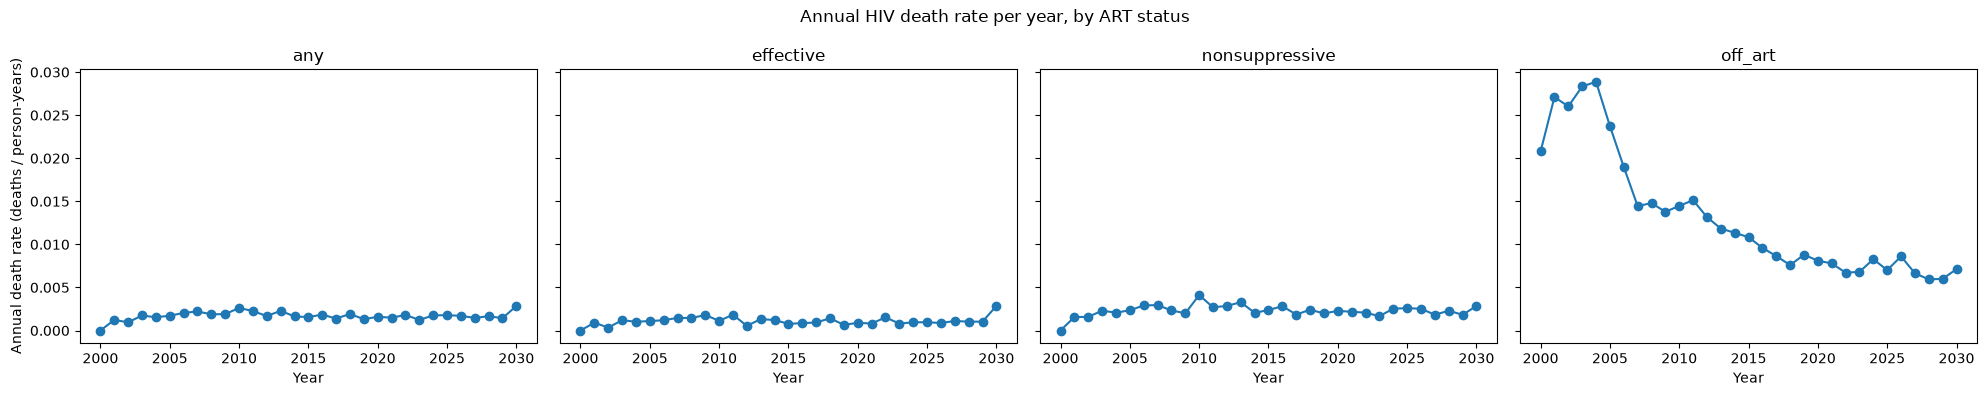

In [5]:
yearly = yearly_mortality_by_category(tracker, yearvec, age_bins, cd4_bins)
print('Annual HIV death rate per year, by ART status:')
print(yearly.pivot_table(index='year', columns='category', values='annual_death_rate').to_string(float_format='%.4f'))
plot_yearly_mortality(yearly)

## Simulated Mortality by Status

### Females

In [13]:
SEX = 'f'  # 'm' or 'f'

summary = summarize_mortality_by_status(tracker, age_bins, cd4_bins, sex=SEX)
print(f'Annual HIV death rate by ART status, age x CD4, sex={SEX}:')
print(summary.pivot_table(index=['age_band', 'cd4_band'], columns='category',
                           values='annual_death_rate').to_string(float_format='%.4f'))

check_off_art_higher(summary)

Annual HIV death rate by ART status, age x CD4, sex=f:
category           off_art  on_effective_art  on_nonsuppressive_art  total
age_band cd4_band                                                         
0-25     0-200      0.6082            0.0163                 0.0294 0.4091
         200-350    0.0626            0.0000                 0.0000 0.0432
         350-500    0.0095            0.0011                 0.0000 0.0083
         500+       0.0047            0.0005                 0.0009 0.0023
25-35    0-200      0.4396            0.0178                 0.0482 0.3137
         200-350    0.0216            0.0018                 0.0018 0.0156
         350-500    0.0072            0.0017                 0.0000 0.0061
         500+       0.0040            0.0004                 0.0007 0.0018
35-45    0-200      0.3587            0.0258                 0.0352 0.2342
         200-350    0.0248            0.0014                 0.0027 0.0172
         350-500    0.0075            0.0010 

category            off_art  on_effective_art  on_nonsuppressive_art
age_band cd4_band                                                   
0-25     0-200     0.608206          0.016341               0.029430
         200-350   0.062577          0.000000               0.000000
         350-500   0.009486          0.001067               0.000000
         500+      0.004686          0.000458               0.000879
25-35    0-200     0.439640          0.017765               0.048193
         200-350   0.021580          0.001751               0.001806
         350-500   0.007243          0.001727               0.000000
         500+      0.003990          0.000353               0.000701
35-45    0-200     0.358725          0.025794               0.035182
         200-350   0.024761          0.001384               0.002672
         350-500   0.007510          0.001001               0.001521
         500+      0.003707          0.000745               0.000924
45+      0-200     0.304854          0.018878               0.036399
         200-350   0.018305          0.001529               0.004272
         350-500   0.006199          0.001077               0.002392
         500+      0.002967          0.000686               0.001074

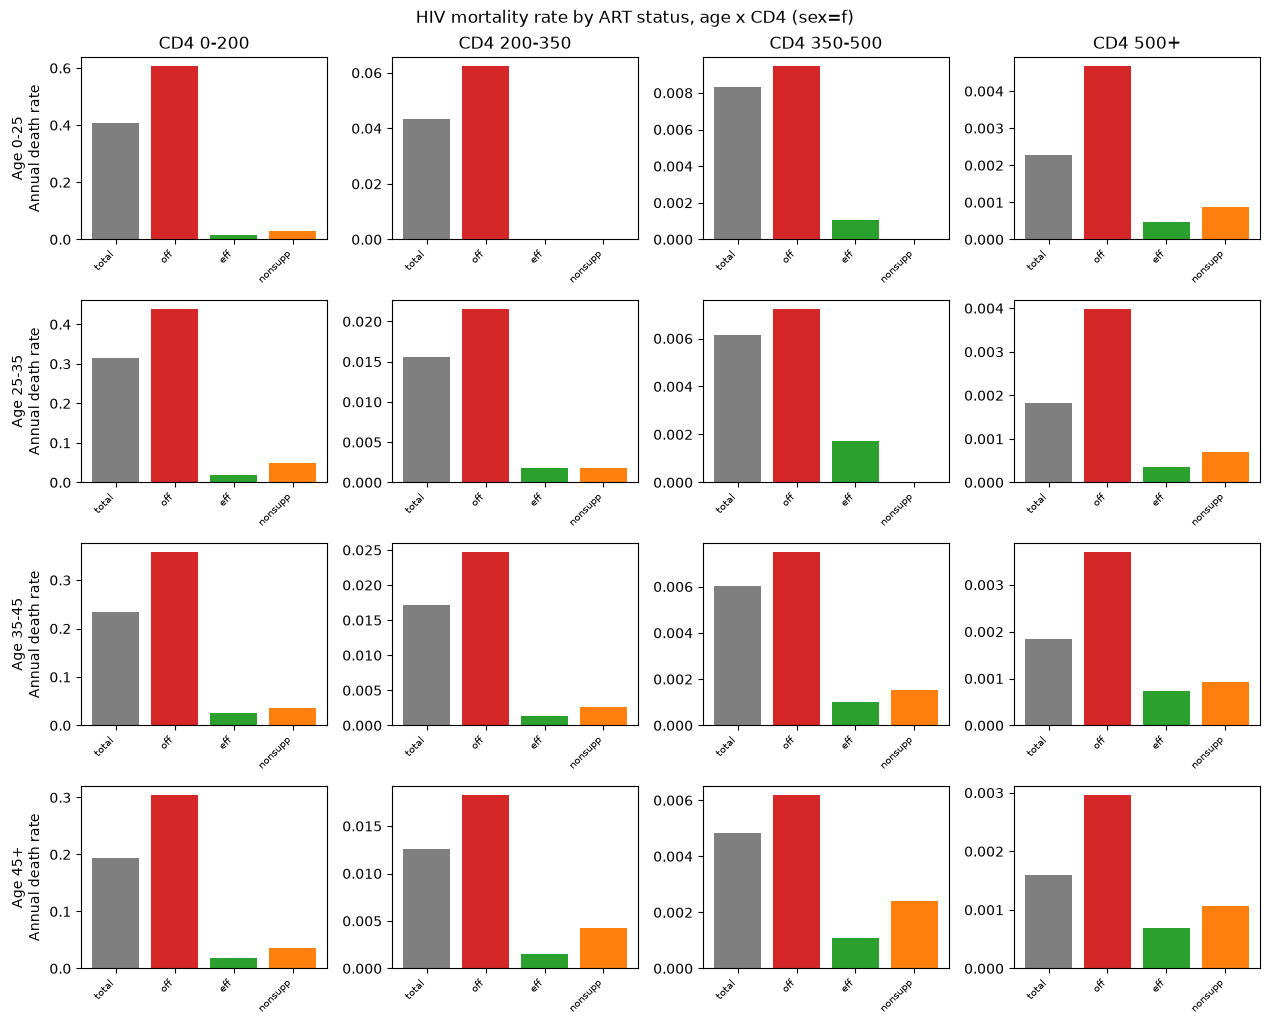

In [14]:
plot_mortality_by_status(summary, age_labels, cd4_labels, sex=SEX)

### Males

In [15]:
SEX = 'm'  # 'm' or 'f'

summary = summarize_mortality_by_status(tracker, age_bins, cd4_bins, sex=SEX)
print(f'Annual HIV death rate by ART status, age x CD4, sex={SEX}:')
print(summary.pivot_table(index=['age_band', 'cd4_band'], columns='category',
                           values='annual_death_rate').to_string(float_format='%.4f'))

check_off_art_higher(summary)

Annual HIV death rate by ART status, age x CD4, sex=m:
category           off_art  on_effective_art  on_nonsuppressive_art  total
age_band cd4_band                                                         
0-25     0-200      0.6398            0.0396                 0.0741 0.4481
         200-350    0.0781            0.0000                 0.0112 0.0556
         350-500    0.0133            0.0014                 0.0027 0.0116
         500+       0.0037            0.0011                 0.0025 0.0025
25-35    0-200      0.4417            0.0263                 0.0934 0.3170
         200-350    0.0462            0.0000                 0.0056 0.0321
         350-500    0.0075            0.0000                 0.0042 0.0067
         500+       0.0026            0.0008                 0.0022 0.0019
35-45    0-200      0.4347            0.0869                 0.0797 0.3289
         200-350    0.0271            0.0000                 0.0146 0.0209
         350-500    0.0067            0.0006 

category            off_art  on_effective_art  on_nonsuppressive_art
age_band cd4_band                                                   
0-25     0-200     0.639841          0.039604               0.074120
         200-350   0.078057          0.000000               0.011159
         350-500   0.013349          0.001446               0.002660
         500+      0.003674          0.001105               0.002512
25-35    0-200     0.441748          0.026287               0.093357
         200-350   0.046234          0.000000               0.005566
         350-500   0.007481          0.000000               0.004153
         500+      0.002560          0.000833               0.002239
35-45    0-200     0.434656          0.086890               0.079705
         200-350   0.027052          0.000000               0.014571
         350-500   0.006692          0.000575               0.002214
         500+      0.002653          0.001039               0.002748
45+      0-200     0.319859          0.031250               0.080306
         200-350   0.020184          0.002485               0.007861
         350-500   0.006936          0.001191               0.003943
         500+      0.003162          0.001025               0.002693

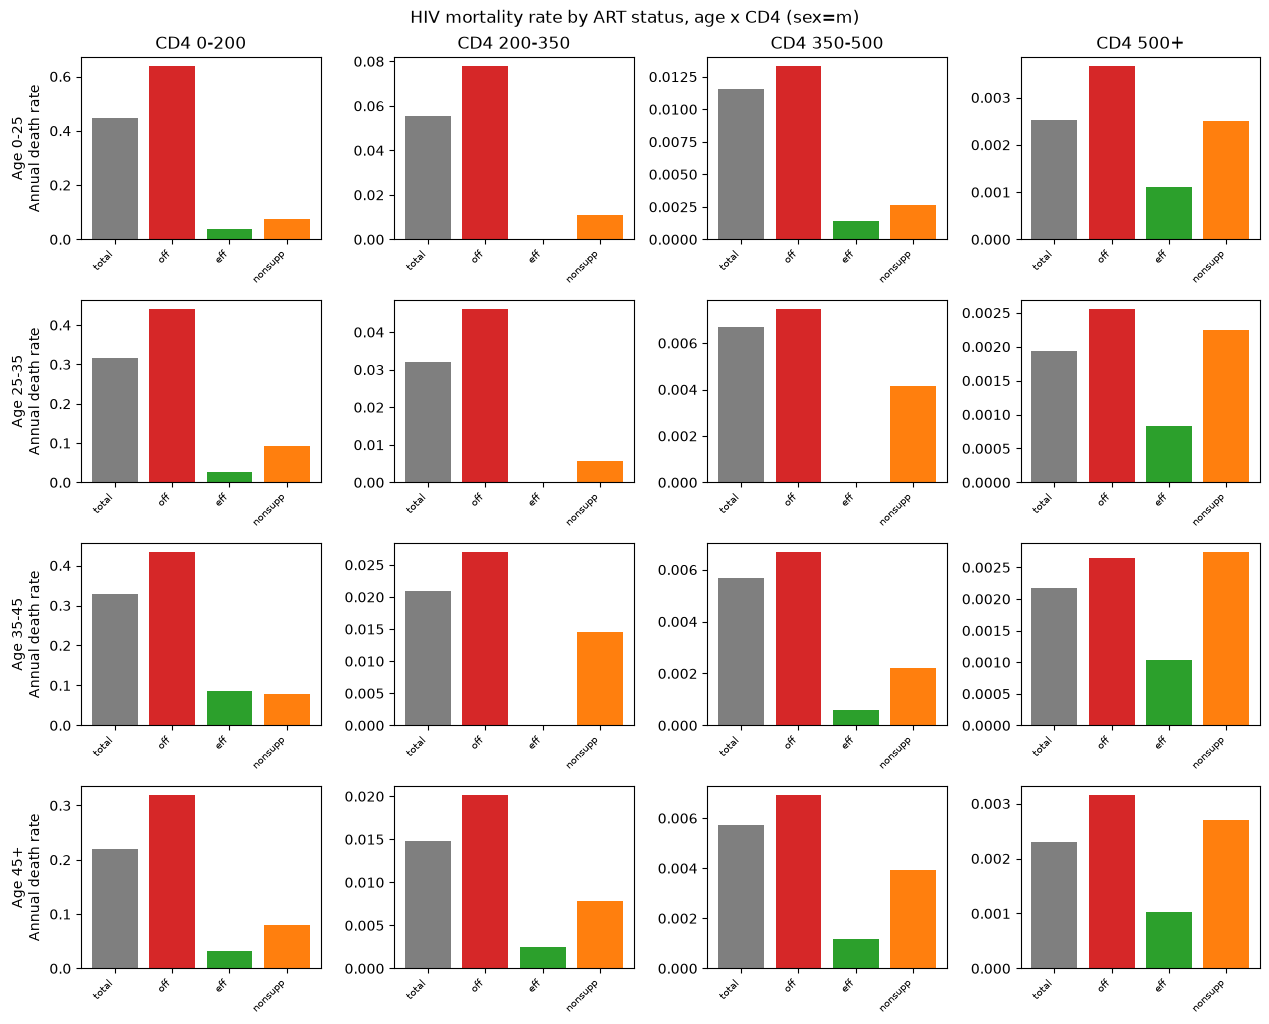

In [16]:
plot_mortality_by_status(summary, age_labels, cd4_labels, sex=SEX)

## Mortality hazards from lookup


--- Off-ART CD4 bins/rates (HIVPars.cd4_death_bins/cd4_death_rates), shared with on-ART ---
 cd4_bin_upper  rate
          1000 0.003
           500 0.003
           350 0.005
           200 0.010
            50 0.050
             0 0.300
  (rel_death = 1.0 multiplies these, for both off-ART and on-ART)
--- Relative-mortality factors (fraction of off-ART rate retained on ART) ---
  rel_art_mortality_effective: 0.25
  rel_art_mortality_unsupp_m (non-suppressive ART, males): 0.7
  rel_art_mortality_unsupp_f (non-suppressive ART, females): 0.35
  rel_death_f (female, on ART, both adherence categories): 0.74
  --> non-suppressive/effective mortality ratio: male=2.80, female=1.40 (rel_death_f cancels out of this ratio, since it applies equally to both categories)
--- On-ART age_mult (HIVPars.art_death_age) ---
 age_lo  age_hi  mult
      0      25  1.00
     25      35  1.10
     35      45  1.21
     45     125  1.32

Worst-case combined multiplier (non-suppressive, oldest age band, male)

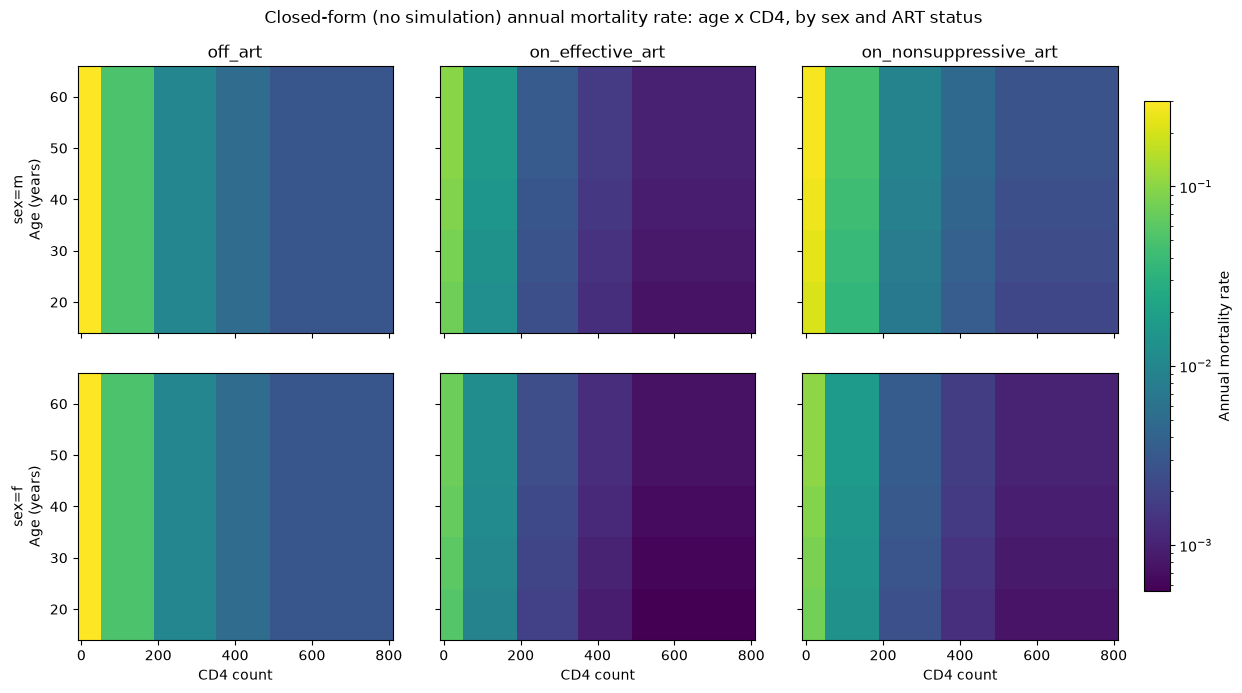

In [17]:
# ==================================================================
# PART 2: closed-form (no simulation) -- exact same math as
# make_p_hiv_death/get_art_mortality_hazard, evaluated directly on an
# age x CD4 grid, pulling live parameter values from sti.HIVPars().
# ==================================================================
print()
print_multiplier_stages()

analytic_age_vals = np.array([20, 30, 40, 50, 60])
analytic_cd4_vals = np.array([0, 100, 200, 300, 400, 500, 600, 700, 800])
analytic_grids = compute_analytic_grids(analytic_age_vals, analytic_cd4_vals)
print_analytic_tables(analytic_age_vals, analytic_cd4_vals, analytic_grids)

fine_age_vals = np.arange(15, 66, 2)
fine_cd4_vals = np.arange(0, 810, 20)
fine_grids = compute_analytic_grids(fine_age_vals, fine_cd4_vals)
plot_analytic_heatmaps(fine_age_vals, fine_cd4_vals, fine_grids)

In [33]:
1/.7

1.4285714285714286